In [12]:
import shutil
import sys
import subprocess
import json
from pathlib import Path

import nibabel as nib
from nibabel.processing import resample_from_to
from nilearn.image import resample_to_img
import numpy as np
import matplotlib.pyplot as plt

In [2]:
RAPIDTIDE_CMD = "/home/bami/anaconda3/envs/JHA-spmCVR/bin/rapidtide"
assert Path(RAPIDTIDE_CMD).exists(), f"rapidtide not found: {RAPIDTIDE_CMD}"
print("RAPIDTIDE_CMD:", RAPIDTIDE_CMD)

RAPIDTIDE_CMD: /home/bami/anaconda3/envs/JHA-spmCVR/bin/rapidtide


In [3]:
# TR 500 == 0.5 sec
TR = 0.5

BASE = Path("/media/bami/JHA/rsCVR/data/Test_1")

T1_PATH = BASE / "3dt1/pr_YMSUK_3DT1TFESAG.nii"
BOLD_4D = BASE / "sr/srYmSUK_RS-fMRI_TR500_4D.nii"
MEAN_BOLD = BASE / "meanBOLD/meanYmSUK_RSfMRITR500_00001.nii"
TPM_PATH = Path("/media/bami/JHA/rsCVR/data/SPM_mask/TPM.nii")

RAPIDTIDE_DIR = BASE / "rapidtide"
OUT_DIR = RAPIDTIDE_DIR
LOG_DIR = RAPIDTIDE_DIR / "logs"
MANIFEST_DIR = RAPIDTIDE_DIR / "manifests"
SPM_BATCH_DIR = BASE / "spm_batch"

OUT_CVR = RAPIDTIDE_DIR / "with_CVR_T1mask_thr050"
OUT_NOCVR = RAPIDTIDE_DIR / "no_CVR_T1mask_thr050"

for d in [RAPIDTIDE_DIR, OUT_DIR, LOG_DIR, MANIFEST_DIR, SPM_BATCH_DIR, OUT_CVR, OUT_NOCVR]:
    d.mkdir(parents=True, exist_ok=True)

OUTPUT_LEVEL = "normal"

RAPIDTIDE_CVR_ROOT = OUT_CVR / "YMSUK_RSfMRI_TR500"
RAPIDTIDE_NOCVR_ROOT = OUT_NOCVR / "YMSUK_RSfMRI_TR500"

MASK_PATH = RAPIDTIDE_DIR / "brainmask_GM_WM_thr050_from_coregT1_in_BOLDspace.nii.gz"
REGRESSOR_PATH = RAPIDTIDE_DIR / "global_mean_regressor_T1_GM_WM_thr050.txt"

for p in [T1_PATH, BOLD_4D, MEAN_BOLD, TPM_PATH]:
    print(p, p.exists())

print("MASK_PATH:", MASK_PATH, MASK_PATH.exists())
print("REGRESSOR_PATH:", REGRESSOR_PATH, REGRESSOR_PATH.exists())

/media/bami/JHA/rsCVR/data/Test_1/3dt1/pr_YMSUK_3DT1TFESAG.nii True
/media/bami/JHA/rsCVR/data/Test_1/sr/srYmSUK_RS-fMRI_TR500_4D.nii True
/media/bami/JHA/rsCVR/data/Test_1/meanBOLD/meanYmSUK_RSfMRITR500_00001.nii True
/media/bami/JHA/rsCVR/data/SPM_mask/TPM.nii True
MASK_PATH: /media/bami/JHA/rsCVR/data/Test_1/rapidtide/brainmask_GM_WM_thr050_from_coregT1_in_BOLDspace.nii.gz False
REGRESSOR_PATH: /media/bami/JHA/rsCVR/data/Test_1/rapidtide/global_mean_regressor_T1_GM_WM_thr050.txt False


In [4]:
t1_img = nib.load(str(T1_PATH))
mean_img = nib.load(str(MEAN_BOLD))
bold_img = nib.load(str(BOLD_4D))

print("T1 shape      :", t1_img.shape)
print("T1 affine     :\n", t1_img.affine)

print("meanBOLD shape:", mean_img.shape)
print("meanBOLD affine:\n", mean_img.affine)

print("BOLD shape    :", bold_img.shape)
print("BOLD affine   :\n", bold_img.affine)

T1 shape      : (512, 512, 400)
T1 affine     :
 [[ 3.92762965e-02 -5.34982048e-02  9.97795227e-01 -9.95040119e-01]
 [-9.99226173e-01  9.01984265e-10  3.93326230e-02  1.55520264e+02]
 [-2.10422562e-03 -9.98567946e-01 -5.34568064e-02  1.26733055e+02]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]]
meanBOLD shape: (128, 128, 32)
meanBOLD affine:
 [[-1.71103001e+00  6.89089894e-02  2.83881128e-01  9.79094925e+01]
 [-7.29702711e-02 -1.71662283e+00 -8.57512951e-02  1.28645172e+02]
 [ 1.45440400e-01 -5.05855083e-02  3.29668903e+00 -7.89352417e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]]
BOLD shape    : (128, 128, 32, 600)
BOLD affine   :
 [[-1.71103001e+00  6.89089894e-02  2.83881128e-01  9.79094925e+01]
 [-7.29702711e-02 -1.71662283e+00 -8.57512951e-02  1.28645172e+02]
 [ 1.45440400e-01 -5.05855083e-02  3.29668903e+00 -7.89352417e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]]


In [5]:
print("Python:", sys.executable)
print("rapidtide path:", shutil.which("rapidtide"))

Python: /home/bami/anaconda3/envs/JHA-spmCVR/bin/python
rapidtide path: None


In [6]:
# Defs
def plot_orth_map_blackbg(path, mask_path=None, title=None,
                          cmap="OrRd_r", pct=75, signed=True):
    path = Path(path)
    img = nib.load(str(path))
    data = img.get_fdata(dtype=np.float32)

    if data.ndim == 4:
        data = data[..., 0]

    if mask_path is not None:
        mask = nib.load(str(mask_path)).get_fdata() > 0
        if mask.shape != data.shape:
            raise ValueError(f"Shape mismatch: data={data.shape}, mask={mask.shape}")
        data = np.where(mask, data, np.nan)

    vals = data[np.isfinite(data)]
    if vals.size == 0:
        raise ValueError(f"No finite values in {path}")

    if signed:
        vmax = np.nanpercentile(np.abs(vals), pct)
        vmin = -vmax
    else:
        vmin = 0
        vmax = np.nanpercentile(vals[vals > 0], pct) if np.any(vals > 0) else np.nanpercentile(vals, pct)

    cmap_obj = plt.get_cmap(cmap).copy()
    cmap_obj.set_bad(color="black")

    x, y, z = data.shape[:3]
    sag = data[x // 2, :, :]
    cor = data[:, y // 2, :]
    axi = data[:, :, z // 2]

    fig, axes = plt.subplots(1, 3, figsize=(12, 4), facecolor="black")

    for ax, slc, name in zip(
        axes,
        [sag, cor, axi],
        ["Sagittal", "Coronal", "Axial"]
    ):
        ax.set_facecolor("black")
        ax.imshow(np.rot90(slc), cmap=cmap_obj, vmin=vmin, vmax=vmax)
        ax.set_title(name, color="white")
        ax.axis("off")

    fig.suptitle(title if title else path.name, color="white")
    fig.tight_layout()
    plt.show()

    print("file :", path)
    print("shape:", img.shape)
    print("zooms:", img.header.get_zooms())
    print("display range:", (vmin, vmax))

In [7]:
### SPM Coregistration + Segmentation in 3DT1

In [8]:
# 
batch_path = SPM_BATCH_DIR / "run_segment_coreg_tissues_YMSUK.m"

c1_native = T1_PATH.parent / ("c1" + T1_PATH.name)
c2_native = T1_PATH.parent / ("c2" + T1_PATH.name)
c3_native = T1_PATH.parent / ("c3" + T1_PATH.name)

matlab_code = f"""
matlabbatch = {{}};

% =============================
% 1. Segment native high-resolution T1
% =============================
matlabbatch{{1}}.spm.spatial.preproc.channel.vols = {{
'{T1_PATH},1'
}};
matlabbatch{{1}}.spm.spatial.preproc.channel.biasreg = 0.001;
matlabbatch{{1}}.spm.spatial.preproc.channel.biasfwhm = 60;
matlabbatch{{1}}.spm.spatial.preproc.channel.write = [0 1];

matlabbatch{{1}}.spm.spatial.preproc.tissue(1).tpm = {{
'{TPM_PATH},1'
}};
matlabbatch{{1}}.spm.spatial.preproc.tissue(1).ngaus = 1;
matlabbatch{{1}}.spm.spatial.preproc.tissue(1).native = [1 0];
matlabbatch{{1}}.spm.spatial.preproc.tissue(1).warped = [0 0];

matlabbatch{{1}}.spm.spatial.preproc.tissue(2).tpm = {{
'{TPM_PATH},2'
}};
matlabbatch{{1}}.spm.spatial.preproc.tissue(2).ngaus = 1;
matlabbatch{{1}}.spm.spatial.preproc.tissue(2).native = [1 0];
matlabbatch{{1}}.spm.spatial.preproc.tissue(2).warped = [0 0];

matlabbatch{{1}}.spm.spatial.preproc.tissue(3).tpm = {{
'{TPM_PATH},3'
}};
matlabbatch{{1}}.spm.spatial.preproc.tissue(3).ngaus = 2;
matlabbatch{{1}}.spm.spatial.preproc.tissue(3).native = [1 0];
matlabbatch{{1}}.spm.spatial.preproc.tissue(3).warped = [0 0];

matlabbatch{{1}}.spm.spatial.preproc.tissue(4).tpm = {{
'{TPM_PATH},4'
}};
matlabbatch{{1}}.spm.spatial.preproc.tissue(4).ngaus = 3;
matlabbatch{{1}}.spm.spatial.preproc.tissue(4).native = [0 0];
matlabbatch{{1}}.spm.spatial.preproc.tissue(4).warped = [0 0];

matlabbatch{{1}}.spm.spatial.preproc.tissue(5).tpm = {{
'{TPM_PATH},5'
}};
matlabbatch{{1}}.spm.spatial.preproc.tissue(5).ngaus = 4;
matlabbatch{{1}}.spm.spatial.preproc.tissue(5).native = [0 0];
matlabbatch{{1}}.spm.spatial.preproc.tissue(5).warped = [0 0];

matlabbatch{{1}}.spm.spatial.preproc.tissue(6).tpm = {{
'{TPM_PATH},6'
}};
matlabbatch{{1}}.spm.spatial.preproc.tissue(6).ngaus = 2;
matlabbatch{{1}}.spm.spatial.preproc.tissue(6).native = [0 0];
matlabbatch{{1}}.spm.spatial.preproc.tissue(6).warped = [0 0];

matlabbatch{{1}}.spm.spatial.preproc.warp.mrf = 1;
matlabbatch{{1}}.spm.spatial.preproc.warp.cleanup = 1;
matlabbatch{{1}}.spm.spatial.preproc.warp.reg = [0 0.001 0.5 0.05 0.2];
matlabbatch{{1}}.spm.spatial.preproc.warp.affreg = 'mni';
matlabbatch{{1}}.spm.spatial.preproc.warp.fwhm = 0;
matlabbatch{{1}}.spm.spatial.preproc.warp.samp = 3;
matlabbatch{{1}}.spm.spatial.preproc.warp.write = [0 0];
matlabbatch{{1}}.spm.spatial.preproc.warp.vox = NaN;
matlabbatch{{1}}.spm.spatial.preproc.warp.bb = [NaN NaN NaN; NaN NaN NaN];

% =============================
% 2. Coregister T1 to meanBOLD and reslice T1 + tissue maps
% =============================
matlabbatch{{2}}.spm.spatial.coreg.estwrite.ref = {{
'{MEAN_BOLD},1'
}};
matlabbatch{{2}}.spm.spatial.coreg.estwrite.source = {{
'{T1_PATH},1'
}};
matlabbatch{{2}}.spm.spatial.coreg.estwrite.other = {{
'{c1_native},1'
'{c2_native},1'
'{c3_native},1'
}};
matlabbatch{{2}}.spm.spatial.coreg.estwrite.eoptions.cost_fun = 'nmi';
matlabbatch{{2}}.spm.spatial.coreg.estwrite.eoptions.sep = [4 2];
matlabbatch{{2}}.spm.spatial.coreg.estwrite.eoptions.tol = ...
[0.02 0.02 0.02 0.001 0.001 0.001 0.01 0.01 0.01 0.001 0.001 0.001];
matlabbatch{{2}}.spm.spatial.coreg.estwrite.eoptions.fwhm = [7 7];
matlabbatch{{2}}.spm.spatial.coreg.estwrite.roptions.interp = 4;
matlabbatch{{2}}.spm.spatial.coreg.estwrite.roptions.wrap = [0 0 0];
matlabbatch{{2}}.spm.spatial.coreg.estwrite.roptions.mask = 0;
matlabbatch{{2}}.spm.spatial.coreg.estwrite.roptions.prefix = 'r';
"""

batch_path.write_text(matlab_code)
print("Saved:", batch_path)

SPM_EXE = "/home/bami/anaconda3/envs/JHA-spmCVR/bin/spm"
cmd_spm = [SPM_EXE, "batch", str(batch_path)]

print(" ".join(cmd_spm))
subprocess.run(cmd_spm, check=True)


# batch_path = SPM_BATCH_DIR / "run_segment_coreg_tissues_YMSUK.m"

# matlab_code = f"""
# matlabbatch = {{}};

# % =============================
# % 1. Segment native high-resolution T1
# % =============================
# matlabbatch{{1}}.spm.spatial.preproc.channel.vols = {{
# '{T1_PATH},1'
# }};
# matlabbatch{{1}}.spm.spatial.preproc.channel.biasreg = 0.001;
# matlabbatch{{1}}.spm.spatial.preproc.channel.biasfwhm = 60;
# matlabbatch{{1}}.spm.spatial.preproc.channel.write = [0 1];

# matlabbatch{{1}}.spm.spatial.preproc.tissue(1).tpm = {{
# '{TPM_PATH},1'
# }};
# matlabbatch{{1}}.spm.spatial.preproc.tissue(1).ngaus = 1;
# matlabbatch{{1}}.spm.spatial.preproc.tissue(1).native = [1 0];
# matlabbatch{{1}}.spm.spatial.preproc.tissue(1).warped = [0 0];

# matlabbatch{{1}}.spm.spatial.preproc.tissue(2).tpm = {{
# '{TPM_PATH},2'
# }};
# matlabbatch{{1}}.spm.spatial.preproc.tissue(2).ngaus = 1;
# matlabbatch{{1}}.spm.spatial.preproc.tissue(2).native = [1 0];
# matlabbatch{{1}}.spm.spatial.preproc.tissue(2).warped = [0 0];

# matlabbatch{{1}}.spm.spatial.preproc.tissue(3).tpm = {{
# '{TPM_PATH},3'
# }};
# matlabbatch{{1}}.spm.spatial.preproc.tissue(3).ngaus = 2;
# matlabbatch{{1}}.spm.spatial.preproc.tissue(3).native = [1 0];
# matlabbatch{{1}}.spm.spatial.preproc.tissue(3).warped = [0 0];

# matlabbatch{{1}}.spm.spatial.preproc.tissue(4).tpm = {{
# '{TPM_PATH},4'
# }};
# matlabbatch{{1}}.spm.spatial.preproc.tissue(4).ngaus = 3;
# matlabbatch{{1}}.spm.spatial.preproc.tissue(4).native = [0 0];
# matlabbatch{{1}}.spm.spatial.preproc.tissue(4).warped = [0 0];

# matlabbatch{{1}}.spm.spatial.preproc.tissue(5).tpm = {{
# '{TPM_PATH},5'
# }};
# matlabbatch{{1}}.spm.spatial.preproc.tissue(5).ngaus = 4;
# matlabbatch{{1}}.spm.spatial.preproc.tissue(5).native = [0 0];
# matlabbatch{{1}}.spm.spatial.preproc.tissue(5).warped = [0 0];

# matlabbatch{{1}}.spm.spatial.preproc.tissue(6).tpm = {{
# '{TPM_PATH},6'
# }};
# matlabbatch{{1}}.spm.spatial.preproc.tissue(6).ngaus = 2;
# matlabbatch{{1}}.spm.spatial.preproc.tissue(6).native = [0 0];
# matlabbatch{{1}}.spm.spatial.preproc.tissue(6).warped = [0 0];

# matlabbatch{{1}}.spm.spatial.preproc.warp.mrf = 1;
# matlabbatch{{1}}.spm.spatial.preproc.warp.cleanup = 1;
# matlabbatch{{1}}.spm.spatial.preproc.warp.reg = [0 0.001 0.5 0.05 0.2];
# matlabbatch{{1}}.spm.spatial.preproc.warp.affreg = 'mni';
# matlabbatch{{1}}.spm.spatial.preproc.warp.fwhm = 0;
# matlabbatch{{1}}.spm.spatial.preproc.warp.samp = 3;
# matlabbatch{{1}}.spm.spatial.preproc.warp.write = [0 0];
# matlabbatch{{1}}.spm.spatial.preproc.warp.vox = NaN;
# matlabbatch{{1}}.spm.spatial.preproc.warp.bb = [NaN NaN NaN; NaN NaN NaN];

# % =============================
# % 2. Coregister T1 to meanBOLD and reslice T1 + c1/c2/c3
# % =============================
# matlabbatch{{2}}.spm.spatial.coreg.estwrite.ref = {{
# '{MEAN_BOLD},1'
# }};
# matlabbatch{{2}}.spm.spatial.coreg.estwrite.source = {{
# '{T1_PATH},1'
# }};
# matlabbatch{{2}}.spm.spatial.coreg.estwrite.other = {{
# '{T1_PATH.parent / ("c1" + T1_PATH.name)},1'
# '{T1_PATH.parent / ("c2" + T1_PATH.name)},1'
# '{T1_PATH.parent / ("c3" + T1_PATH.name)},1'
# }};
# matlabbatch{{2}}.spm.spatial.coreg.estwrite.eoptions.cost_fun = 'nmi';
# matlabbatch{{2}}.spm.spatial.coreg.estwrite.eoptions.sep = [4 2];
# matlabbatch{{2}}.spm.spatial.coreg.estwrite.eoptions.tol = ...
# [0.02 0.02 0.02 0.001 0.001 0.001 0.01 0.01 0.01 0.001 0.001 0.001];
# matlabbatch{{2}}.spm.spatial.coreg.estwrite.eoptions.fwhm = [7 7];
# matlabbatch{{2}}.spm.spatial.coreg.estwrite.roptions.interp = 4;
# matlabbatch{{2}}.spm.spatial.coreg.estwrite.roptions.wrap = [0 0 0];
# matlabbatch{{2}}.spm.spatial.coreg.estwrite.roptions.mask = 0;
# matlabbatch{{2}}.spm.spatial.coreg.estwrite.roptions.prefix = 'r';
# """

# batch_path.write_text(matlab_code)
# print("Saved:", batch_path)

# SPM_EXE = "/home/bami/anaconda3/envs/JHA-spmCVR/bin/spm"
# cmd_spm = [SPM_EXE, "batch", str(batch_path)]

# print(" ".join(cmd_spm))
# subprocess.run(cmd_spm, check=True)

Saved: /media/bami/JHA/rsCVR/data/Test_1/spm_batch/run_segment_coreg_tissues_YMSUK.m
/home/bami/anaconda3/envs/JHA-spmCVR/bin/spm batch /media/bami/JHA/rsCVR/data/Test_1/spm_batch/run_segment_coreg_tissues_YMSUK.m
SPM25, version 25.01.02 (standalone)
MATLAB, version 25.2.0.3177638 (R2025b) Update 5
 ___  ____  __  __                                            
/ __)(  _ \(  \/  )                                           
\__ \ )___/ )    (   Statistical Parametric Mapping           
(___/(__)  (_/\/\_)  SPM25 - https://www.fil.ion.ucl.ac.uk/spm/



------------------------------------------------------------------------
08-Jun-2026 13:19:03 - Running job #1
------------------------------------------------------------------------
08-Jun-2026 13:19:03 - Running 'Segment'

SPM25: spm_preproc_run                             13:19:03 - 08/06/2026
Segment /media/bami/JHA/rsCVR/data/Test_1/3dt1/pr_YMSUK_3DT1TFESAG.nii,1
Completed                               :          13:45:16 - 08/06/2026

CompletedProcess(args=['/home/bami/anaconda3/envs/JHA-spmCVR/bin/spm', 'batch', '/media/bami/JHA/rsCVR/data/Test_1/spm_batch/run_segment_coreg_tissues_YMSUK.m'], returncode=0)

In [9]:
# 
rT1 = T1_PATH.parent / ("r" + T1_PATH.name)

c1 = T1_PATH.parent / ("rc1" + T1_PATH.name)
c2 = T1_PATH.parent / ("rc2" + T1_PATH.name)
c3 = T1_PATH.parent / ("rc3" + T1_PATH.name)

spm_outputs = [rT1, c1, c2, c3]

for p in spm_outputs:
    print(p, p.exists(), p.stat().st_size if p.exists() else None)

missing = [p for p in spm_outputs if not p.exists()]
if missing:
    raise FileNotFoundError("\n".join(map(str, missing)))

/media/bami/JHA/rsCVR/data/Test_1/3dt1/rpr_YMSUK_3DT1TFESAG.nii True 1048928
/media/bami/JHA/rsCVR/data/Test_1/3dt1/rc1pr_YMSUK_3DT1TFESAG.nii True 524640
/media/bami/JHA/rsCVR/data/Test_1/3dt1/rc2pr_YMSUK_3DT1TFESAG.nii True 524640
/media/bami/JHA/rsCVR/data/Test_1/3dt1/rc3pr_YMSUK_3DT1TFESAG.nii True 524640


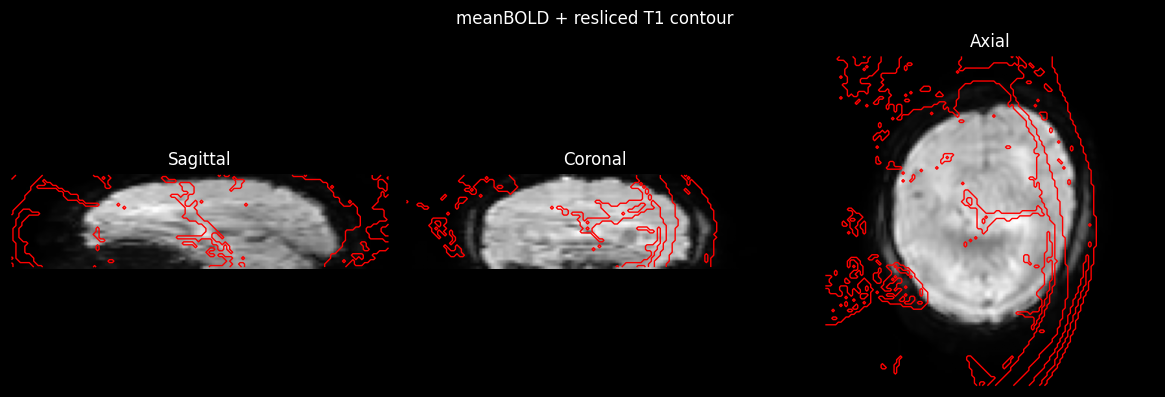

In [10]:
# 
def overlay_contour_on_mean(mean_path, overlay_path, pct=50, title=None):
    mean_img = nib.load(str(mean_path))
    mean = mean_img.get_fdata(dtype=np.float32)

    ov_img = nib.load(str(overlay_path))
    ov = ov_img.get_fdata(dtype=np.float32)

    if mean.shape != ov.shape:
        raise ValueError(f"Shape mismatch: mean={mean.shape}, overlay={ov.shape}")

    brain = mean > np.percentile(mean[mean > 0], 20)
    coords = np.argwhere(brain)
    cx, cy, cz = np.round(coords.mean(axis=0)).astype(int)

    ov_thr = np.percentile(ov[ov > 0], pct)

    slices = [
        ("Sagittal", mean[cx, :, :], ov[cx, :, :]),
        ("Coronal",  mean[:, cy, :], ov[:, cy, :]),
        ("Axial",    mean[:, :, cz], ov[:, :, cz]),
    ]

    fig, axes = plt.subplots(1, 3, figsize=(12, 4), facecolor="black")

    for ax, (name, mean_slc, ov_slc) in zip(axes, slices):
        ax.set_facecolor("black")
        ax.imshow(np.rot90(mean_slc), cmap="gray")
        ax.contour(np.rot90(ov_slc > ov_thr), levels=[0.5], colors="red", linewidths=1)
        ax.set_title(name, color="white")
        ax.axis("off")

    fig.suptitle(title if title else Path(overlay_path).name, color="white")
    plt.tight_layout()
    plt.show()

overlay_contour_on_mean(MEAN_BOLD, rT1, pct=30, title="meanBOLD + resliced T1 contour")

In [9]:
# Confirm SPM outputs

c1 = T1_PATH.parent / ("rc1" + T1_PATH.name)
c2 = T1_PATH.parent / ("rc2" + T1_PATH.name)
c3 = T1_PATH.parent / ("rc3" + T1_PATH.name)

spm_outputs = [c1, c2, c3]

for p in spm_outputs:
    print(p, p.exists(), p.stat().st_size if p.exists() else None)

missing = [p for p in spm_outputs if not p.exists()]
if missing:
    raise FileNotFoundError("\n".join(map(str, missing)))


# T1_COREG = T1_PATH.parent / ("coreg_" + T1_PATH.name)
# c1 = T1_PATH.parent / ("c1" + T1_COREG.name)
# c2 = T1_PATH.parent / ("c2" + T1_COREG.name)
# c3 = T1_PATH.parent / ("c3" + T1_COREG.name)
# spm_outputs = [T1_COREG, c1, c2, c3]
# for p in spm_outputs:
#     print(p, p.exists())
# missing = [p for p in spm_outputs if not p.exists()]
# if missing:
#     raise FileNotFoundError(
#         "SPM outputs are missing.\n"
#         "Missing files:\n" + "\n".join(map(str, missing))
#     )

/media/bami/JHA/rsCVR/data/Test_1/3dt1/rc1pr_YMSUK_3DT1TFESAG.nii True 524640
/media/bami/JHA/rsCVR/data/Test_1/3dt1/rc2pr_YMSUK_3DT1TFESAG.nii True 524640
/media/bami/JHA/rsCVR/data/Test_1/3dt1/rc3pr_YMSUK_3DT1TFESAG.nii True 524640


In [10]:
thr = 0.5

gm = nib.load(str(c1)).get_fdata(dtype=np.float32)
wm = nib.load(str(c2)).get_fdata(dtype=np.float32)
csf = nib.load(str(c3)).get_fdata(dtype=np.float32)

brain_prob = gm + wm + csf
mask = (brain_prob > thr).astype(np.uint8)

mean_img = nib.load(str(MEAN_BOLD))

if mask.shape != mean_img.shape:
    raise ValueError(f"Shape mismatch: mask={mask.shape}, meanBOLD={mean_img.shape}")

nib.save(
    nib.Nifti1Image(mask, mean_img.affine, mean_img.header),
    str(MASK_PATH)
)

print("Saved BOLD-space mask:", MASK_PATH)
print("BOLD shape:", nib.load(str(BOLD_4D)).shape[:3])
print("mask shape:", mask.shape)
print("mask voxels:", mask.sum())
print("mask ratio :", mask.mean())

Saved BOLD-space mask: /media/bami/JHA/rsCVR/data/Test_1/rapidtide/brainmask_GM_WM_thr050_from_coregT1_in_BOLDspace.nii.gz
BOLD shape: (128, 128, 32)
mask shape: (128, 128, 32)
mask voxels: 296686
mask ratio : 0.5658836364746094


In [19]:
'''
# Mask creation :: GM+WM

thr = 0.5

GM_PROB = nib.load(str(c1))
WM_PROB = nib.load(str(c2))
CSF_PROB = nib.load(str(c3))

gm_bold_img = resample_to_img(
    source_img=GM_PROB,
    target_img=str(MEAN_BOLD),
    interpolation="continuous",
    force_resample=True,
    copy_header=True,
)

wm_bold_img = resample_to_img(
    source_img=WM_PROB,
    target_img=str(MEAN_BOLD),
    interpolation="continuous",
    force_resample=True,
    copy_header=True,
)

csf_bold_img = resample_to_img(
    source_img=CSF_PROB,
    target_img=str(MEAN_BOLD),
    interpolation="continuous",
    force_resample=True,
    copy_header=True,
)

gm_bold = gm_bold_img.get_fdata(dtype=np.float32)
wm_bold = wm_bold_img.get_fdata(dtype=np.float32)
csf_bold = csf_bold_img.get_fdata(dtype=np.float32)

brain_prob = gm_bold + wm_bold + csf_bold
mask = (brain_prob > thr).astype(np.uint8)

nib.save(
    nib.Nifti1Image(
        mask,
        nib.load(str(MEAN_BOLD)).affine,
        nib.load(str(MEAN_BOLD)).header
    ),
    str(MASK_PATH)
)

print("Saved BOLD-space brain mask:", MASK_PATH)
print("BOLD shape:", nib.load(str(BOLD_4D)).shape[:3])
print("mask shape:", mask.shape)
print("mask voxels:", mask.sum())
print("mask ratio :", mask.mean())
'''

Saved BOLD-space brain mask: /media/bami/JHA/rsCVR/data/Test_1/rapidtide/brainmask_GM_WM_thr050_from_coregT1_in_BOLDspace.nii.gz
BOLD shape: (128, 128, 32)
mask shape: (128, 128, 32)
mask voxels: 296652
mask ratio : 0.5658187866210938


In [13]:
'''
# meanBOLD resampling
mask_resampled_img = resample_to_img(
    source_img=str(T1_MASK_PATH),
    target_img=str(MEAN_BOLD),
    interpolation="nearest",
    force_resample=True,
    copy_header=True,
)

nib.save(mask_resampled_img, str(MASK_PATH))

mask = nib.load(str(MASK_PATH)).get_fdata() > 0

print("Saved BOLD-space mask:", MASK_PATH)
print("BOLD shape:", nib.load(str(BOLD_4D)).shape[:3])
print("mask shape:", mask.shape)
print("mask voxels:", mask.sum())
print("mask ratio :", mask.mean())
'''

NameError: name 'T1_MASK_PATH' is not defined

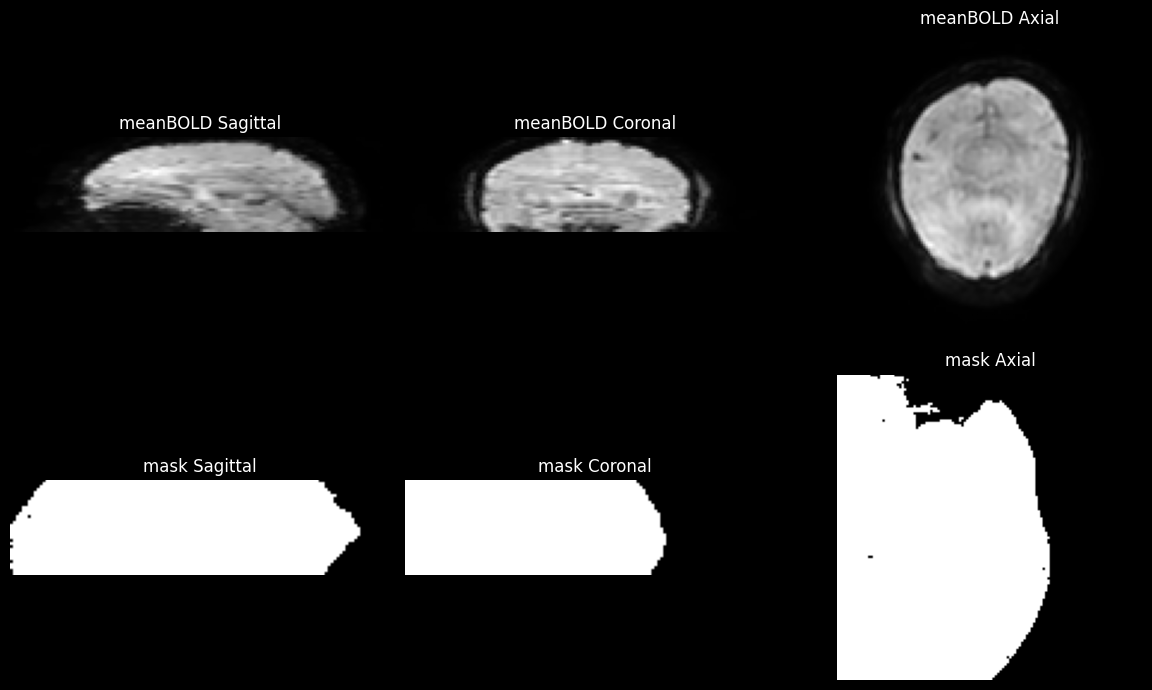

In [11]:
# Confirm MASK
def quick_check_mean_mask(mean_path, mask_path):
    mean_img = nib.load(str(mean_path))
    mean_data = mean_img.get_fdata(dtype=np.float32)

    mask_img = nib.load(str(mask_path))
    mask_data = mask_img.get_fdata() > 0

    x, y, z = mean_data.shape

    slices = [
        ("Sagittal", mean_data[x//2, :, :], mask_data[x//2, :, :]),
        ("Coronal", mean_data[:, y//2, :], mask_data[:, y//2, :]),
        ("Axial", mean_data[:, :, z//2], mask_data[:, :, z//2]),
    ]

    fig, axes = plt.subplots(2, 3, figsize=(12, 7), facecolor="black")

    for i, (name, mean_slc, mask_slc) in enumerate(slices):
        axes[0, i].imshow(np.rot90(mean_slc), cmap="gray")
        axes[0, i].set_title(f"meanBOLD {name}", color="white")
        axes[0, i].axis("off")

        axes[1, i].imshow(np.rot90(mask_slc), cmap="gray")
        axes[1, i].set_title(f"mask {name}", color="white")
        axes[1, i].axis("off")

    for ax in axes.ravel():
        ax.set_facecolor("black")

    plt.tight_layout()
    plt.show()

quick_check_mean_mask(MEAN_BOLD, MASK_PATH)

In [16]:
imgs = {
    "MEAN_BOLD": MEAN_BOLD,
    "BOLD_4D": BOLD_4D,
    "T1_PATH": T1_PATH,
    "c1": c1,
    "c2": c2,
    "c3": c3,
    "MASK_PATH": MASK_PATH,
}

for name, path in imgs.items():
    path = Path(path)
    print("\n===", name, "===")
    print("path  :", path)
    print("exists:", path.exists())
    if path.exists():
        img = nib.load(str(path))
        print("shape :", img.shape)
        print("zooms :", img.header.get_zooms())
        print("affine:\n", img.affine)


=== MEAN_BOLD ===
path  : /media/bami/JHA/rsCVR/data/Test_1/meanBOLD/meanYmSUK_RSfMRITR500_00001.nii
exists: True
shape : (128, 128, 32)
zooms : (np.float32(1.7187499), np.float32(1.7187499), np.float32(3.31))
affine:
 [[-1.71103001e+00  6.89089894e-02  2.83881128e-01  9.79094925e+01]
 [-7.29702711e-02 -1.71662283e+00 -8.57512951e-02  1.28645172e+02]
 [ 1.45440400e-01 -5.05855083e-02  3.29668903e+00 -7.89352417e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]]

=== BOLD_4D ===
path  : /media/bami/JHA/rsCVR/data/Test_1/sr/srYmSUK_RS-fMRI_TR500_4D.nii
exists: True
shape : (128, 128, 32, 600)
zooms : (np.float32(1.7187499), np.float32(1.7187499), np.float32(3.31), np.float32(0.0))
affine:
 [[-1.71103001e+00  6.89089894e-02  2.83881128e-01  9.79094925e+01]
 [-7.29702711e-02 -1.71662283e+00 -8.57512951e-02  1.28645172e+02]
 [ 1.45440400e-01 -5.05855083e-02  3.29668903e+00 -7.89352417e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]]

=== T1_PAT

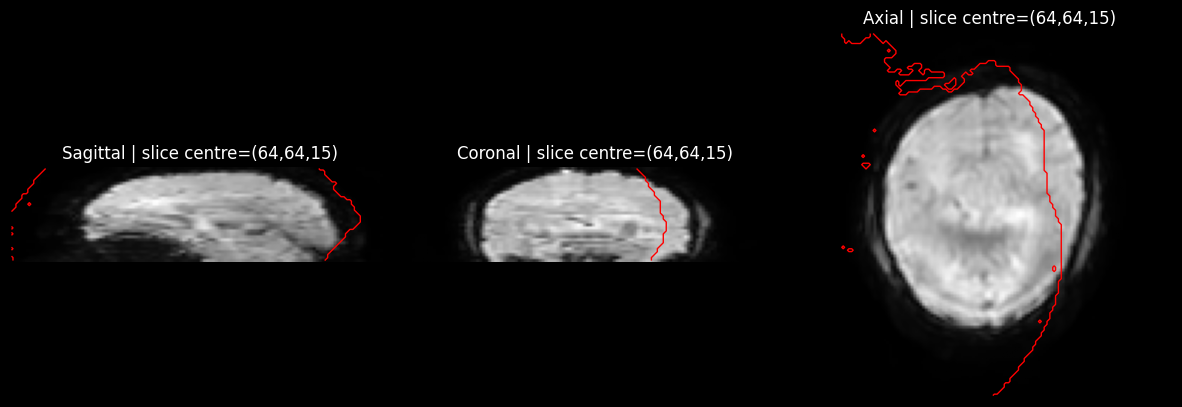

In [15]:
def overlay_mask_on_mean(mean_path, mask_path):
    mean_img = nib.load(str(mean_path))
    mean = mean_img.get_fdata(dtype=np.float32)

    mask_img = nib.load(str(mask_path))
    mask = mask_img.get_fdata() > 0

    if mean.shape != mask.shape:
        raise ValueError(f"Shape mismatch: mean={mean.shape}, mask={mask.shape}")

    # meanBOLD brain centre 기준으로 slice 선택
    brain = mean > np.percentile(mean[mean > 0], 20)
    coords = np.argwhere(brain)
    cx, cy, cz = np.round(coords.mean(axis=0)).astype(int)

    slices = [
        ("Sagittal", mean[cx, :, :], mask[cx, :, :]),
        ("Coronal",  mean[:, cy, :], mask[:, cy, :]),
        ("Axial",    mean[:, :, cz], mask[:, :, cz]),
    ]

    fig, axes = plt.subplots(1, 3, figsize=(12, 4), facecolor="black")

    for ax, (name, mean_slc, mask_slc) in zip(axes, slices):
        ax.set_facecolor("black")
        ax.imshow(np.rot90(mean_slc), cmap="gray")
        ax.contour(np.rot90(mask_slc), levels=[0.5], colors="red", linewidths=1)
        ax.set_title(f"{name} | slice centre=({cx},{cy},{cz})", color="white")
        ax.axis("off")

    plt.tight_layout()
    plt.show()

overlay_mask_on_mean(MEAN_BOLD, MASK_PATH)

In [17]:
T1_DIR = T1_PATH.parent

patterns = [
    "c1pr_YMSUK_3DT1TFESAG.nii",
    "c2pr_YMSUK_3DT1TFESAG.nii",
    "c3pr_YMSUK_3DT1TFESAG.nii",
    "rc1pr_YMSUK_3DT1TFESAG.nii",
    "rc2pr_YMSUK_3DT1TFESAG.nii",
    "rc3pr_YMSUK_3DT1TFESAG.nii",
    "rpr_YMSUK_3DT1TFESAG.nii",
    "m*.nii",
    "y_*.nii",
    "iy_*.nii",
]

for pat in patterns:
    for f in T1_DIR.glob(pat):
        if f.name != T1_PATH.name:
            print("remove:", f)
            f.unlink()

for f in [MASK_PATH, REGRESSOR_PATH]:
    if Path(f).exists():
        print("remove:", f)
        Path(f).unlink()

remove: /media/bami/JHA/rsCVR/data/Test_1/3dt1/c1pr_YMSUK_3DT1TFESAG.nii
remove: /media/bami/JHA/rsCVR/data/Test_1/3dt1/c2pr_YMSUK_3DT1TFESAG.nii
remove: /media/bami/JHA/rsCVR/data/Test_1/3dt1/c3pr_YMSUK_3DT1TFESAG.nii
remove: /media/bami/JHA/rsCVR/data/Test_1/3dt1/rc1pr_YMSUK_3DT1TFESAG.nii
remove: /media/bami/JHA/rsCVR/data/Test_1/3dt1/rc2pr_YMSUK_3DT1TFESAG.nii
remove: /media/bami/JHA/rsCVR/data/Test_1/3dt1/rc3pr_YMSUK_3DT1TFESAG.nii
remove: /media/bami/JHA/rsCVR/data/Test_1/3dt1/rpr_YMSUK_3DT1TFESAG.nii
remove: /media/bami/JHA/rsCVR/data/Test_1/3dt1/mrpr_YMSUK_3DT1TFESAG.nii
remove: /media/bami/JHA/rsCVR/data/Test_1/3dt1/mcoreg_pr_YMSUK_3DT1TFESAG.nii
remove: /media/bami/JHA/rsCVR/data/Test_1/3dt1/mpr_YMSUK_3DT1TFESAG.nii
remove: /media/bami/JHA/rsCVR/data/Test_1/rapidtide/brainmask_GM_WM_thr050_from_coregT1_in_BOLDspace.nii.gz


In [ ]:
# Regressor Generation
bold_img = nib.load(str(BOLD_4D))
bold = bold_img.get_fdata(dtype=np.float32)

mask = nib.load(str(MASK_PATH)).get_fdata() > 0

if bold.shape[:3] != mask.shape:
    raise ValueError(f"Shape mismatch: BOLD={bold.shape[:3]}, mask={mask.shape}")

ts = bold[mask, :].mean(axis=0)

np.savetxt(REGRESSOR_PATH, ts, fmt="%.8f")

print("Saved regressor:", REGRESSOR_PATH)
print("timepoints:", len(ts))
print("mean:", np.mean(ts))
print("std :", np.std(ts))

In [8]:
# Pilot rows

pilot_row_cvr = {
    "subject": "YMSUK",
    "run": "RS-fMRI_TR500_with_CVR",
    "rapidtide_output_root": str(RAPIDTIDE_CVR_ROOT),
    "brain_mask": str(MASK_PATH),
}

pilot_row_nocvr = {
    "subject": "YMSUK",
    "run": "RS-fMRI_TR500_no_CVR",
    "rapidtide_output_root": str(RAPIDTIDE_NOCVR_ROOT),
    "brain_mask": str(MASK_PATH),
}

In [ ]:
## 1) Rapidtide with --CVR option

In [9]:
# 3. Execution :: Rapidtide with CVR

cmd_cvr = [
    RAPIDTIDE_CMD,
    str(BOLD_4D),
    str(RAPIDTIDE_CVR_ROOT),
    "--regressor", str(REGRESSOR_PATH),
    "--regressortstep", str(TR),
    "--CVR",
    "--brainmask", str(MASK_PATH),
    "--datatstep", str(TR),
    "--searchrange", "-5", "20",
    "--numnull", "0",
    "--outputlevel", "normal",
    "--spatialfilt", "-1",
]

print(" ".join(cmd_cvr))
subprocess.run(cmd_cvr, check=True)

/home/bami/anaconda3/envs/JHA-spmCVR/bin/rapidtide /media/bami/JHA/rsCVR/data/Test_1/sr/srYmSUK_RS-fMRI_TR500_4D.nii /media/bami/JHA/rsCVR/data/Test_1/rapidtide/with_CVR/YMSUK_RSfMRI_TR500 --regressor /media/bami/JHA/rsCVR/data/Test_1/rapidtide/global_mean_regressor.txt --regressortstep 0.5 --CVR --brainmask /media/bami/JHA/rsCVR/data/Test_1/rapidtide/brainmask_from_meanBOLD.nii.gz --datatstep 0.5 --searchrange -5 20 --numnull 0 --outputlevel normal --spatialfilt -1


starting rapidtide 3.1.9
524288 spatial locations, 600 timepoints


setting initregressorinclude mask to gray matter mask
setting corrmaskinclude mask to gray matter mask
setting refineinclude mask to gray matter mask
setting offsetinclude mask to gray matter mask
overriding despeckle_passes
overriding preservefiltering
overriding passes
overriding refineoffset
overriding refinedelay
overriding zerooutbadfit
overriding refinedespeckled
overriding saveintermediatemaps
no aggressive optimization
will not use numba even if present
garbage collection is on
Loaded pyfftw wisdom from /home/bami/.config/rapidtide_wisdom_FFTW_ESTIMATE.txt
loading data from /media/bami/JHA/rsCVR/data/Test_1/sr/srYmSUK_RS-fMRI_TR500_4D.nii
startpoint set to  0
endpoint set to maximum, ( 599 )
startpoint set to  0
endpoint set to maximum, ( 599 )
applying gaussian spatial filter to timepoints 0 to 599 with sigma=1.1245832443237305


Timepoint: 100%|██████████| 600/600 [00:11<00:00, 51.36timepoints/s]
constructing global mean include mask
constructing refine include mask
constructing offset include mask
constructing global mean signal using sum
used 406829 voxels to calculate initial regressor signal
constructing global mean signal using sum
used 406829 voxels to calculate whole brain signal
constructing global mean signal using sum
used 406829 voxels to calculate gray matter signal
constructing global mean signal using sum
used 406829 voxels to calculate white matter signal
constructing global mean signal using sum
used 406829 voxels to calculate CSF signal
using externally supplied probe regressor /media/bami/JHA/rsCVR/data/Test_1/rapidtide/global_mean_regressor.txt
no regressor start time specified - defaulting to 0.0
synctime is -10.5
total probe regressor offset is 0.0
filtering to arb band
setting up fast resampling with padtime = 50.0
checking reference regressor autocorrelation properties
searching for side

garbage collected - unable to collect 804 objects
lowering smoothing filter pad time to 25.0
allocated 665.579 megabytes locally for correlation
allocated 1.829 gigabytes locally for delay refinement
check_autocorrelation: 40 40 10 40


...


MAD of regression fit derivative ratios = 77.6249300761414


Voxel: 100%|██████████| 406829/406829 [00:06<00:00, 60960.09voxels/s]
garbage collected - unable to collect 66 objects

Lagged timecourses created for 406829 voxels
garbage collected
End lagged timecourse creation
Start filtering operation
Voxel: 100%|██████████| 406829/406829 [04:36<00:00, 1470.29voxels/s]
End filtering operation
constructing global mean signal using sum
used 406829 voxels to calculate whole brain signal
constructing global mean signal using sum
used 406829 voxels to calculate gray matter signal
constructing global mean signal using sum
used 406829 voxels to calculate white matter signal
constructing global mean signal using sum
used 406829 voxels to calculate CSF signal

Start lagged timecourse creation
Voxel:   3%|▎         | 12092/406829 [00:00<00:06, 60493.64voxels/s]


filtering fmri_data to sLFO band
rerunning sLFO fit to get filtered R value


Voxel: 100%|██████████| 406829/406829 [00:06<00:00, 60484.85voxels/s]
garbage collected - unable to collect 593 objects

Lagged timecourses created for 406829 voxels
garbage collected
End lagged timecourse creation
Start filtering operation
Voxel: 100%|██████████| 406829/406829 [04:35<00:00, 1478.07voxels/s]
done


CompletedProcess(args=['/home/bami/anaconda3/envs/JHA-spmCVR/bin/rapidtide', '/media/bami/JHA/rsCVR/data/Test_1/sr/srYmSUK_RS-fMRI_TR500_4D.nii', '/media/bami/JHA/rsCVR/data/Test_1/rapidtide/with_CVR/YMSUK_RSfMRI_TR500', '--regressor', '/media/bami/JHA/rsCVR/data/Test_1/rapidtide/global_mean_regressor.txt', '--regressortstep', '0.5', '--CVR', '--brainmask', '/media/bami/JHA/rsCVR/data/Test_1/rapidtide/brainmask_from_meanBOLD.nii.gz', '--datatstep', '0.5', '--searchrange', '-5', '20', '--numnull', '0', '--outputlevel', 'normal', '--spatialfilt', '-1'], returncode=0)

rsCVR: /media/bami/JHA/rsCVR/data/Test_1/rapidtide/with_CVR/YMSUK_RSfMRI_TR500_desc-CVR_map.nii.gz True


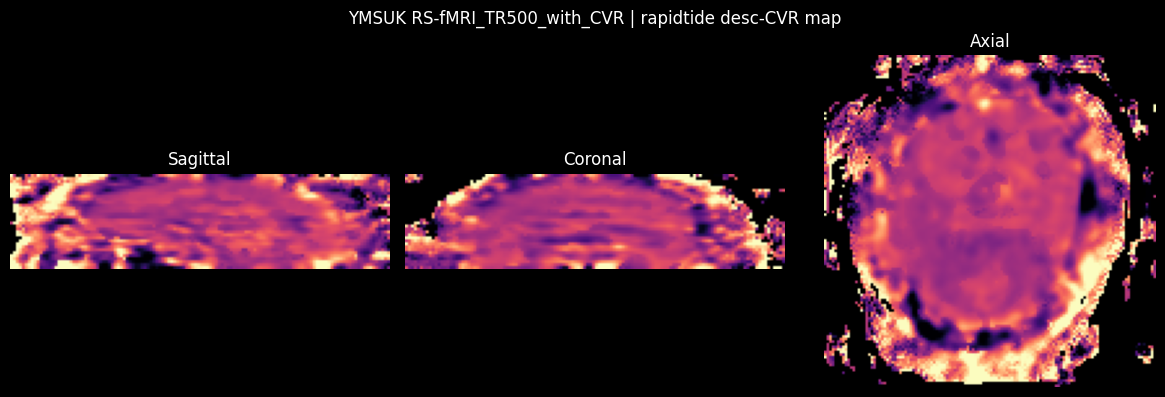

file : /media/bami/JHA/rsCVR/data/Test_1/rapidtide/with_CVR/YMSUK_RSfMRI_TR500_desc-CVR_map.nii.gz
shape: (128, 128, 32)
zooms: (np.float32(1.7187499), np.float32(1.7187499), np.float32(3.31))
display range: (np.float32(-12.324571), np.float32(12.324571))


In [14]:
# 4. Rapidtide with CVR : rsCVR map

RSCVR_PATH = Path(str(pilot_row_cvr["rapidtide_output_root"]) + "_desc-CVR_map.nii.gz")
BRAIN_MASK_PATH = Path(pilot_row_cvr["brain_mask"])

print("rsCVR path:", RSCVR_PATH, RSCVR_PATH.exists())

plot_orth_map_blackbg(
    RSCVR_PATH,
    mask_path=BRAIN_MASK_PATH,
    title=f"{pilot_row_cvr['subject']} {pilot_row_cvr['run']} | rapidtide desc-CVR map",
    cmap="magma",
    pct=90,
    signed=True
)

refined lag: /media/bami/JHA/rsCVR/data/Test_1/rapidtide/with_CVR/YMSUK_RSfMRI_TR500_desc-maxtimerefined_map.nii.gz True
raw lag    : /media/bami/JHA/rsCVR/data/Test_1/rapidtide/with_CVR/YMSUK_RSfMRI_TR500_desc-maxtime_map.nii.gz True


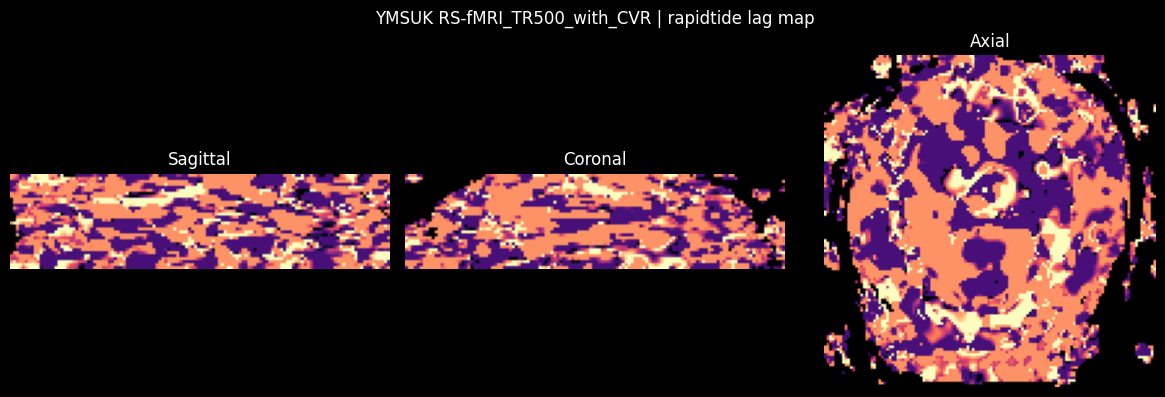

file : /media/bami/JHA/rsCVR/data/Test_1/rapidtide/with_CVR/YMSUK_RSfMRI_TR500_desc-maxtimerefined_map.nii.gz
shape: (128, 128, 32)
zooms: (np.float32(1.7187499), np.float32(1.7187499), np.float32(3.31))
display range: (np.float32(-9.119991), np.float32(9.119991))


In [15]:
# 5. Rapidtide with CVR : lag map

LAG_REFINED_PATH = Path(str(pilot_row_cvr["rapidtide_output_root"]) + "_desc-maxtimerefined_map.nii.gz")
LAG_RAW_PATH = Path(str(pilot_row_cvr["rapidtide_output_root"]) + "_desc-maxtime_map.nii.gz")

print("refined lag:", LAG_REFINED_PATH, LAG_REFINED_PATH.exists())
print("raw lag    :", LAG_RAW_PATH, LAG_RAW_PATH.exists())

if LAG_REFINED_PATH.exists():
    LAG_PATH = LAG_REFINED_PATH
elif LAG_RAW_PATH.exists():
    LAG_PATH = LAG_RAW_PATH
else:
    raise FileNotFoundError("No official rapidtide lag map found.")

plot_orth_map_blackbg(
    LAG_PATH,
    mask_path=Path(pilot_row_cvr["brain_mask"]),
    title=f"{pilot_row_cvr['subject']} {pilot_row_cvr['run']} | rapidtide lag map",
    cmap="magma",
    pct=90,
    signed=True
)

In [ ]:
## 2) Rapidtide without --CVR option

In [16]:
# 3. Execution :: Rapidtide without CVR

cmd_nocvr = [
    RAPIDTIDE_CMD,
    str(BOLD_4D),
    str(RAPIDTIDE_NOCVR_ROOT),
    "--regressor", str(REGRESSOR_PATH),
    "--regressortstep", str(TR),
    "--brainmask", str(MASK_PATH),
    "--datatstep", str(TR),
    "--searchrange", "-5", "20",
    "--numnull", "0",
    "--outputlevel", "normal",
    "--spatialfilt", "-1",
]

print(" ".join(cmd_nocvr))
subprocess.run(cmd_nocvr, check=True)

/home/bami/anaconda3/envs/JHA-spmCVR/bin/rapidtide /media/bami/JHA/rsCVR/data/Test_1/sr/srYmSUK_RS-fMRI_TR500_4D.nii /media/bami/JHA/rsCVR/data/Test_1/rapidtide/no_CVR/YMSUK_RSfMRI_TR500 --regressor /media/bami/JHA/rsCVR/data/Test_1/rapidtide/global_mean_regressor.txt --regressortstep 0.5 --brainmask /media/bami/JHA/rsCVR/data/Test_1/rapidtide/brainmask_from_meanBOLD.nii.gz --datatstep 0.5 --searchrange -5 20 --numnull 0 --outputlevel normal --spatialfilt -1


starting rapidtide 3.1.9
524288 spatial locations, 600 timepoints


setting initregressorinclude mask to gray matter mask
setting corrmaskinclude mask to gray matter mask
setting refineinclude mask to gray matter mask
setting offsetinclude mask to gray matter mask
overriding refineoffset
overriding refinedelay
overriding zerooutbadfit
overriding preservefiltering
overriding passes
overriding despeckle_passes
overriding refinedespeckled
overriding saveintermediatemaps
no aggressive optimization
will not use numba even if present
garbage collection is on
Loaded pyfftw wisdom from /home/bami/.config/rapidtide_wisdom_FFTW_ESTIMATE.txt
loading data from /media/bami/JHA/rsCVR/data/Test_1/sr/srYmSUK_RS-fMRI_TR500_4D.nii
startpoint set to  0
endpoint set to maximum, ( 599 )
startpoint set to  0
endpoint set to maximum, ( 599 )
applying gaussian spatial filter to timepoints 0 to 599 with sigma=1.1245832443237305


Timepoint: 100%|██████████| 600/600 [00:11<00:00, 51.16timepoints/s]
constructing global mean include mask
constructing refine include mask
constructing offset include mask
constructing global mean signal using sum
used 406829 voxels to calculate initial regressor signal
constructing global mean signal using sum
used 406829 voxels to calculate whole brain signal
constructing global mean signal using sum
used 406829 voxels to calculate gray matter signal
constructing global mean signal using sum
used 406829 voxels to calculate white matter signal
constructing global mean signal using sum
used 406829 voxels to calculate CSF signal
using externally supplied probe regressor /media/bami/JHA/rsCVR/data/Test_1/rapidtide/global_mean_regressor.txt
no regressor start time specified - defaulting to 0.0
synctime is -0.5
total probe regressor offset is 0.0
filtering to lfo band
setting up fast resampling with padtime = 50.0


*********************
Pass number 1
checking reference regressor autocorr

garbage collected - unable to collect 804 objects
lowering smoothing filter pad time to 25.0
allocated 665.579 megabytes locally for correlation
allocated 1.829 gigabytes locally for delay refinement
allocated 8.487 gigabytes locally for refinement
check_autocorrelation: 40 40 10 40


Voxel: 100%|██████████| 406829/406829 [06:47<00:00, 999.55voxels/s] 
garbage collected - unable to collect 99 objects

Similarity function calculated on 406829 voxels
garbage collected


Time lag estimation pass 1
Voxel:  37%|███▋      | 148704/406829 [00:53<01:32, 2776.40voxels/s]
Traceback (most recent call last):
  File "/home/bami/anaconda3/envs/JHA-spmCVR/bin/rapidtide", line 6, in <module>
    sys.exit(entrypoint())
  File "/home/bami/anaconda3/envs/JHA-spmCVR/lib/python3.10/site-packages/rapidtide/scripts/rapidtide.py", line 24, in entrypoint
    rapidtide_workflow.rapidtide_main(rapidtide_parser.process_args(inputargs=None))
  File "/home/bami/anaconda3/envs/JHA-spmCVR/lib/python3.10/site-packages/rapidtide/workflows/rapidtide.py", line 2533, in rapidtide_main
    internaldespeckleincludemask = tide_fitSimFuncMap.fitSimFunc(
  File "/home/bami/anaconda3/envs/JHA-spmCVR/lib/python3.10/site-packages/rapidtide/workflows/fitSimFuncMap.py", line 816, in fitSimFunc
    voxelsprocesse

KeyboardInterrupt: 

In [ ]:
# 4. Rapidtide without CVR : rsCVR map

RSCVR_NOCVR_PATH = Path(str(pilot_row_nocvr["rapidtide_output_root"]) + "_desc-maxcorr_map.nii.gz")
BRAIN_MASK_PATH = Path(pilot_row_nocvr["brain_mask"])

print("no-CVR rsCVR-like path:", RSCVR_NOCVR_PATH, RSCVR_NOCVR_PATH.exists())

plot_orth_map_blackbg(
    RSCVR_NOCVR_PATH,
    mask_path=BRAIN_MASK_PATH,
    title=f"{pilot_row_nocvr['subject']} {pilot_row_nocvr['run']} | rapidtide desc-maxcorr map",
    cmap="magma",
    pct=90,
    signed=True
)

In [ ]:
# 5. Rapidtide without CVR : lag map

LAG_REFINED_PATH = Path(str(pilot_row_nocvr["rapidtide_output_root"]) + "_desc-maxtimerefined_map.nii.gz")
LAG_RAW_PATH = Path(str(pilot_row_nocvr["rapidtide_output_root"]) + "_desc-maxtime_map.nii.gz")

print("refined lag:", LAG_REFINED_PATH, LAG_REFINED_PATH.exists())
print("raw lag    :", LAG_RAW_PATH, LAG_RAW_PATH.exists())

if LAG_REFINED_PATH.exists():
    LAG_PATH = LAG_REFINED_PATH
elif LAG_RAW_PATH.exists():
    LAG_PATH = LAG_RAW_PATH
else:
    raise FileNotFoundError("No official rapidtide lag map found.")

plot_orth_map_blackbg(
    LAG_PATH,
    mask_path=Path(pilot_row_nocvr["brain_mask"]),
    title=f"{pilot_row_nocvr['subject']} {pilot_row_nocvr['run']} | rapidtide lag map",
    cmap="magma",
    pct=90,
    signed=True
)